# 基于流量剖面的不同类型的位置数量
根据之前对于城市区域的划分规则，根据区域内部但车流量、区域单车的出流/入流对不同区域进行数量统计。起始点、终点在同一区域内即为区域内部流量，起始点在区域内，终点在区域外即为出流，反之则为入流。

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
import sys
import math
import datetime
from math import radians, cos, sin, asin, sqrt
from matplotlib.colors import LogNorm
from io import StringIO
from sklearn import linear_model
#import tensorflow as tf
from scipy import optimize
#from scipy.optimize import curve_fit
plt.rcParams["font.sans-serif"]=["SimHei"] #用来正常显示中文标签
plt.rcParams["axes.unicode_minus"]=False #用来正常显示负号

In [2]:
from math import sin, asin, cos, radians, fabs, sqrt
EARTH_RADIUS=6371 
def hav(theta):
    s = sin(theta / 2)
    return s * s
def get_distance_hav(lat0, lng0, lat1, lng1):    #lat纬度
    lat0 = radians(lat0)
    lat1 = radians(lat1)
    lng0 = radians(lng0)
    lng1 = radians(lng1)
    dlng = fabs(lng0 - lng1)
    dlat = fabs(lat0 - lat1)
    h = hav(dlat) + cos(lat0) * cos(lat1) * hav(dlng)
    distance = 2 * EARTH_RADIUS * asin(sqrt(h))
    return distance

In [3]:
cen_x=[121.492494]   #城市中心坐标
cen_y=[31.225719]

In [4]:
df=pd.read_csv('df.csv')   #筛选数据后的单车数据
df

,orderid,userid,bikeid,biketype,starttime,geohashed_start_loc,geohashed_end_loc,start_x,start_y,end_x,end_y,BJ,Travel_time(s),speed
0,1893973,451147,210617,2,2017-05-14 22:16:50,wx4snhx,wx4snhj,116.289597,40.103531,116.286850,40.100784,1,141,2.727397
1,4657992,1061133,465394,1,2017-05-14 22:16:52,wx4dr59,wx4dquz,116.325302,39.790421,116.322556,39.797287,1,265,3.013957
2,2965085,549189,310572,1,2017-05-14 22:16:51,wx4fgur,wx4fu5n,116.542282,39.882431,116.551895,39.875565,1,625,1.792963
3,3936364,467449,403224,1,2017-05-14 22:16:50,wx4g27p,wx4g266,116.388474,39.963455,116.381607,39.959335,1,250,2.972972
4,5163705,917620,509044,1,2017-05-14 22:16:53,wx4gd2e,wx4g6pw,116.470871,39.993668,116.464005,39.988174,1,231,3.661382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094262,308143,683030,42881,1,2017-05-23 06:20:55,wx4gjs9,wx4gjs0,116.610947,39.927750,116.609573,39.925003,1,103,3.176235
3094263,1886236,394183,209895,2,2017-05-23 06:20:57,wx4fd57,wx4fd4d,116.459885,39.832993,116.458511,39.828873,1,560,0.844479
3094264,2162814,878844,235870,2,2017-05-23 06:20:56,wx4fbyv,wx4g08r,116.407700,39.896164,116.399460,39.904404,1,385,2.999509
3094265,3702730,104540,380669,1,2017-05-23 06:20:56,wx4u11d,wx4u10c,116.414566,40.087051,116.413193,40.082932,1,123,3.842861


In [5]:
sid=(np.load("500m起始区域id(bj).npy")).tolist()
sid1=pd.Series(sid)
eid=(np.load("500m终点区域id(bj).npy")).tolist()
eid1=pd.Series(eid)

In [7]:
df["sid"]=sid1   #起始id
df["eid"]=eid1   #终点id

In [8]:
s_eid=[]
for i in range(0,len(df)):
    c=[]
    a=df.iloc[i]["sid"]
    b=df.iloc[i]["eid"]
    c.append(a)
    c.append(b)
    s_eid.append(c)

In [9]:
for i in range(0,len(s_eid)):
    hr=s_eid[i]
    s_eid[i]=str(hr)

In [10]:
s_eid1=pd.Series(s_eid)
s_eid1

0             [941, 9347]
1          [50459, 47949]
2           [4148, 58023]
3           [9126, 19416]
4           [6347, 23909]
                ...      
3094262     [7521, 22824]
3094263    [10753, 54699]
3094264    [14429, 14445]
3094265     [3574, 11820]
3094266    [57346, 62927]
Length: 3094267, dtype: object

In [11]:
df["s_eid"]=s_eid1

In [12]:
e_sid=[]
for i in range(0,len(df)):
    c=[]
    a=df.iloc[i]["sid"]
    b=df.iloc[i]["eid"]
    c.append(b)
    c.append(a)
    e_sid.append(c)

In [13]:
for i in range(0,len(e_sid)):
    hr=e_sid[i]
    e_sid[i]=str(hr)

In [14]:
e_sid1=pd.Series(e_sid)
e_sid1

0             [9347, 941]
1          [47949, 50459]
2           [58023, 4148]
3           [19416, 9126]
4           [23909, 6347]
                ...      
3094262     [22824, 7521]
3094263    [54699, 10753]
3094264    [14445, 14429]
3094265     [11820, 3574]
3094266    [62927, 57346]
Length: 3094267, dtype: object

In [15]:
df["e_sid"]=e_sid1

In [16]:
df1_1=df[df["sid"]!=-1]

In [17]:
df1_2=df1_1[df1_1["eid"]!=-1]

In [18]:
df10=df1_2[df1_2["sid"]!=df1_2["eid"]]      #不在同一区域内的数据
df10

,orderid,userid,bikeid,biketype,starttime,geohashed_start_loc,geohashed_end_loc,start_x,start_y,end_x,end_y,BJ,Travel_time(s),speed,sid,eid,s_eid,e_sid
0,1893973,451147,210617,2,2017-05-14 22:16:50,wx4snhx,wx4snhj,116.289597,40.103531,116.286850,40.100784,1,141,2.727397,941,9347,"[941, 9347]","[9347, 941]"
1,4657992,1061133,465394,1,2017-05-14 22:16:52,wx4dr59,wx4dquz,116.325302,39.790421,116.322556,39.797287,1,265,3.013957,50459,47949,"[50459, 47949]","[47949, 50459]"
2,2965085,549189,310572,1,2017-05-14 22:16:51,wx4fgur,wx4fu5n,116.542282,39.882431,116.551895,39.875565,1,625,1.792963,4148,58023,"[4148, 58023]","[58023, 4148]"
3,3936364,467449,403224,1,2017-05-14 22:16:50,wx4g27p,wx4g266,116.388474,39.963455,116.381607,39.959335,1,250,2.972972,9126,19416,"[9126, 19416]","[19416, 9126]"
4,5163705,917620,509044,1,2017-05-14 22:16:53,wx4gd2e,wx4g6pw,116.470871,39.993668,116.464005,39.988174,1,231,3.661382,6347,23909,"[6347, 23909]","[23909, 6347]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094262,308143,683030,42881,1,2017-05-23 06:20:55,wx4gjs9,wx4gjs0,116.610947,39.927750,116.609573,39.925003,1,103,3.176235,7521,22824,"[7521, 22824]","[22824, 7521]"
3094263,1886236,394183,209895,2,2017-05-23 06:20:57,wx4fd57,wx4fd4d,116.459885,39.832993,116.458511,39.828873,1,560,0.844479,10753,54699,"[10753, 54699]","[54699, 10753]"
3094264,2162814,878844,235870,2,2017-05-23 06:20:56,wx4fbyv,wx4g08r,116.407700,39.896164,116.399460,39.904404,1,385,2.999509,14429,14445,"[14429, 14445]","[14445, 14429]"
3094265,3702730,104540,380669,1,2017-05-23 06:20:56,wx4u11d,wx4u10c,116.414566,40.087051,116.413193,40.082932,1,123,3.842861,3574,11820,"[3574, 11820]","[11820, 3574]"


In [19]:
se1_1=df10["s_eid"].value_counts()   #从某地到某地的流量
inde=(se1_1.index).tolist()
valu=(se1_1.values).tolist()

In [20]:
lin1=[]
for i in range(0,len(inde)):
    lin=[]
    lin.append(inde[i])
    lin.append(valu[i])
    lin1.append(lin)

In [21]:
dict1=dict(lin1)   #A到B的流量
dict1

{'[61807, 56328]': 1766,
 '[50633, 57310]': 1305,
 '[11177, 21429]': 1289,
 '[64727, 64922]': 1227,
 '[16607, 55829]': 1194,
 '[31422, 56328]': 1168,
 '[49515, 28679]': 1123,
 '[34396, 49515]': 1121,
 '[14954, 64687]': 1115,
 '[52928, 63926]': 1105,
 '[49515, 62305]': 1063,
 '[4420, 9732]': 1048,
 '[64922, 27185]': 1046,
 '[9831, 16583]': 1045,
 '[181, 2260]': 1012,
 '[50, 7114]': 1002,
 '[59609, 56606]': 988,
 '[20490, 13660]': 988,
 '[57310, 31173]': 983,
 '[15043, 1330]': 983,
 '[827, 13171]': 970,
 '[8921, 21429]': 964,
 '[11375, 16583]': 962,
 '[4802, 64795]': 954,
 '[18538, 14646]': 953,
 '[59120, 64727]': 943,
 '[7357, 10638]': 939,
 '[181, 12062]': 938,
 '[63340, 57310]': 926,
 '[9585, 12787]': 925,
 '[63225, 60180]': 924,
 '[5369, 16054]': 906,
 '[18246, 5004]': 905,
 '[8706, 2696]': 901,
 '[9275, 7802]': 892,
 '[57310, 50633]': 888,
 '[64795, 4802]': 887,
 '[19666, 497]': 885,
 '[1330, 15043]': 885,
 '[194, 18538]': 884,
 '[5992, 8396]': 874,
 '[62048, 64795]': 870,
 '[47772,

In [22]:
set1=set(df10["s_eid"])
l1=list(set1)   #独特

In [23]:
l2=[]                          #反的
for i in range(0,len(l1)):  
    a=l1[i]
    b=df10[df10["s_eid"]==a]
    c=b.iloc[0]["e_sid"]
    l2.append(c)
    #print(i)

KeyboardInterrupt: 

In [ ]:
flag1=[]                       #标记存在往返的两地
flag1_f=[]
flag0=[]                       #标记不存在往返两地
for i in range(0,len(l2)):
    fl=l2[i]
    p=fl in dict1
    va=l1[i]
    if(p==True):
          
        flag1.append(va)   #正
        flag1_f.append(fl) #反
    else:
        
        flag0.append(va)

In [26]:
fa=[]                   #标记已读
for i in range(0,len(flag1)):
    fa.append(0)

In [27]:
d=[]
for i in range(0,len(fa)):
    c=[]
    a=fa[i]
    b=flag1[i]
    c.append(b)
    c.append(a)
    d.append(c)

In [28]:
dictl=dict(d)
dictl

{'[18203, 61420]': 0,
 '[63333, 58035]': 0,
 '[8713, 18538]': 0,
 '[17222, 65380]': 0,
 '[6019, 17680]': 0,
 '[14335, 23085]': 0,
 '[17201, 64094]': 0,
 '[64037, 66444]': 0,
 '[63782, 64554]': 0,
 '[6593, 5148]': 0,
 '[17625, 25990]': 0,
 '[62473, 62362]': 0,
 '[55235, 58664]': 0,
 '[60150, 46819]': 0,
 '[3104, 20242]': 0,
 '[64786, 60073]': 0,
 '[64037, 23957]': 0,
 '[8855, 9277]': 0,
 '[10928, 15837]': 0,
 '[22846, 3101]': 0,
 '[28459, 23362]': 0,
 '[59006, 56868]': 0,
 '[59062, 25543]': 0,
 '[65663, 66463]': 0,
 '[66257, 26021]': 0,
 '[11362, 18636]': 0,
 '[3973, 20864]': 0,
 '[35786, 45810]': 0,
 '[44123, 23957]': 0,
 '[6149, 19061]': 0,
 '[4595, 14285]': 0,
 '[45012, 56425]': 0,
 '[52934, 64334]': 0,
 '[8595, 7802]': 0,
 '[56659, 49666]': 0,
 '[51938, 40109]': 0,
 '[8461, 4075]': 0,
 '[50649, 59292]': 0,
 '[55715, 2568]': 0,
 '[19091, 14846]': 0,
 '[64334, 53719]': 0,
 '[53701, 36104]': 0,
 '[58001, 31479]': 0,
 '[25662, 22704]': 0,
 '[14965, 18066]': 0,
 '[57283, 26175]': 0,
 '[4

In [29]:
al1=[]   #地点                #存在往返地的流量
al2=[]   #差
al2_1=[]#和
T1=[]   #两地之间的流量
T2=[]
for i in range(0,len(dictl)):
    a=flag1[i]
    b=flag1_f[i]
    f1=dictl[a]
    #f2=dictl[b]
    if(f1==0):
        a1=dict1[a]   #A-B 的流量
        b1=dict1[b]   #B-A的流量
        T1.append(a1)
        T2.append(b1)
        num=a1-b1        #差值
        num1=a1+b1   #和
        al1.append(a)
        al2.append(num)    #差值
        al2_1.append(num1) #和
        dictl[a]=1
        dictl[b]=1

In [33]:
df8_1=df1_2[df1_2["sid"]==df1_2["eid"]]      #在同一区域内的数据
df8_1

,orderid,userid,bikeid,biketype,starttime,geohashed_start_loc,geohashed_end_loc,start_x,start_y,end_x,end_y,BJ,Travel_time(s),speed,sid,eid,s_eid,e_sid
6,495333,185893,67441,1,2017-05-14 22:16:53,wx4emgw,wx4emgk,116.277237,39.966202,116.274490,39.964828,1,126,2.218662,17297,17297,"[17297, 17297]","[17297, 17297]"
17,1119812,72084,137713,2,2017-05-14 22:16:58,wx4f6s6,wx4f6s1,116.480484,39.794540,116.479111,39.793167,1,63,3.056071,66145,66145,"[66145, 66145]","[66145, 66145]"
19,1745122,647684,196465,2,2017-05-14 22:17:00,wx4g323,wx4g328,116.424179,39.948349,116.422806,39.949722,1,164,1.172994,1029,1029,"[1029, 1029]","[1029, 1029]"
64,1927777,753891,213795,2,2017-05-14 22:17:21,wx4gkju,wx4gkn5,116.549149,39.978561,116.547775,39.979935,1,311,0.618906,9654,9654,"[9654, 9654]","[9654, 9654]"
72,764025,852654,101207,1,2017-05-14 22:17:23,wx4fc0c,wx4fc02,116.413193,39.863205,116.411819,39.860458,1,138,2.370955,53402,53402,"[53402, 53402]","[53402, 53402]"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3094219,1675977,986520,189813,2,2017-05-23 06:20:39,wx4g4sd,wx4g4s4,116.480484,39.927750,116.480484,39.925003,1,88,3.471051,13159,13159,"[13159, 13159]","[13159, 13159]"
3094232,3451860,120784,356447,1,2017-05-23 06:20:40,wx4g4fv,wx4g4fq,116.495590,39.918137,116.496964,39.915390,1,97,3.372764,5004,5004,"[5004, 5004]","[5004, 5004]"
3094249,2821294,736434,297275,2,2017-05-23 06:20:44,wx4fcp1,wx4fcnf,116.413193,39.897537,116.414566,39.896164,1,115,1.673264,4471,4471,"[4471, 4471]","[4471, 4471]"
3094253,3971890,376406,406493,1,2017-05-23 06:20:49,wx4f6vd,wx4f6tx,116.491470,39.801407,116.487350,39.801407,1,96,3.666263,47989,47989,"[47989, 47989]","[47989, 47989]"


In [34]:
same_loca=df8_1["sid"].value_counts()
same_loca

52397    1361
58506    1120
48636     875
64922     637
65518     582
         ... 
10065       1
20060       1
1621        1
53254       1
25011       1
Name: sid, Length: 7422, dtype: int64

In [35]:
same_loca1=(same_loca.index).tolist()#有内环流量的区域
same_loca1

[52397,
 58506,
 48636,
 64922,
 65518,
 11508,
 9940,
 904,
 63198,
 56642,
 18246,
 1042,
 56328,
 50599,
 59909,
 54137,
 61562,
 23413,
 45766,
 60807,
 11782,
 37984,
 13192,
 11457,
 64037,
 2696,
 66582,
 8931,
 50638,
 61430,
 181,
 21273,
 2964,
 57310,
 3424,
 8357,
 65377,
 22384,
 65530,
 11177,
 994,
 19359,
 967,
 40836,
 56206,
 58001,
 64727,
 6660,
 63477,
 1210,
 4708,
 27185,
 597,
 55829,
 21644,
 405,
 24007,
 21429,
 11961,
 1444,
 58838,
 56712,
 16199,
 61418,
 511,
 44692,
 65156,
 18344,
 18319,
 9732,
 13171,
 50459,
 8396,
 12062,
 8706,
 1649,
 57354,
 17635,
 44521,
 11128,
 64879,
 63019,
 61981,
 25955,
 19378,
 9341,
 51352,
 515,
 12361,
 54647,
 62305,
 3800,
 53402,
 61559,
 18247,
 14480,
 17402,
 20090,
 25957,
 2738,
 11608,
 59120,
 5992,
 59408,
 64156,
 4678,
 2343,
 65143,
 17829,
 55302,
 12307,
 16583,
 61264,
 10638,
 7160,
 7802,
 58327,
 9278,
 2650,
 60057,
 36788,
 14684,
 19117,
 3888,
 49515,
 49754,
 827,
 52223,
 1385,
 23308,
 8375

In [36]:
loca1=(df1_2["sid"]).tolist()
loca2=(df1_2["eid"]).tolist()

In [37]:
local3=[]           #统计所有的区域
local3.extend(loca1)     
local3.extend(loca2)

In [38]:
local3=pd.Series(local3)

In [39]:
diff_loca=local3.value_counts()

In [40]:
diff_loca1=(diff_loca.index).tolist()  
diff_loca1    #所有不同区域

[64727,
 57310,
 64922,
 56328,
 181,
 49515,
 48636,
 8396,
 56642,
 64795,
 7114,
 56606,
 21429,
 994,
 51352,
 16583,
 9732,
 61559,
 64687,
 52397,
 827,
 63477,
 4708,
 13192,
 2696,
 14782,
 7160,
 58506,
 2267,
 511,
 28679,
 59280,
 15445,
 27185,
 16607,
 50599,
 11508,
 54137,
 9585,
 2598,
 8822,
 194,
 63198,
 18246,
 18737,
 59120,
 64037,
 49825,
 66582,
 56712,
 49754,
 2271,
 3424,
 44692,
 11885,
 17402,
 13171,
 56707,
 1042,
 2955,
 23427,
 18964,
 2964,
 33563,
 64879,
 65518,
 17509,
 58831,
 7324,
 11177,
 5468,
 8089,
 61562,
 20090,
 155,
 55235,
 44123,
 36788,
 7357,
 25955,
 65530,
 1444,
 22181,
 4420,
 5527,
 59909,
 11089,
 2632,
 20663,
 62305,
 21824,
 8931,
 10795,
 22474,
 5004,
 63926,
 6509,
 50633,
 597,
 12787,
 55829,
 904,
 7719,
 5992,
 38764,
 59322,
 62461,
 17829,
 1823,
 47772,
 2576,
 54647,
 29207,
 62364,
 9713,
 28325,
 18552,
 20574,
 10154,
 65156,
 50,
 20981,
 273,
 19592,
 4687,
 2260,
 66047,
 19378,
 8357,
 19460,
 18538,
 13494,

In [41]:
sa_l=len(same_loca1)   #有内环流量的区域
di_l=len(diff_loca1)   #所有有行车记录的流量

In [43]:
un_l=di_l-sa_l    #无内环流量的区域

In [45]:
#np.save("num_list1",num_list)
#np.save("name_list1",name_list)

In [49]:
#num1=[]              
num1=0                                             #只有区域自流量的数目
num2=0                                             #自环 有进  无出
num3=0                                             #自环 有出 无进
num4=0                                             #自环 有出 有进
for i in range(0,len(same_loca1)):
    z=same_loca1[i]
    dtf1=df1_2[df1_2["sid"]==z]    
    dtf1_1=dtf1[dtf1["sid"]!=dtf1["eid"]]
    l1=len(dtf1_1)
    
    dtf2=df1_2[df1_2["eid"]==z]
    dtf2_1=dtf2[dtf2["sid"]!=dtf2["eid"]]
    l2=len(dtf2_1)
    if(l1==0):
        if(l2==0):
            num1=num1+1      #数目
        else:
            num2=num2+1  
    else:
        if(l2==0):
            num3=num3+1      #数目
        else:
            num4=num4+1  
    #print(i)  

In [53]:
unsame_loca=[]
for i in range(0,len(diff_loca1)):
    loci=diff_loca1[i]
    p=loci in same_loca1                   #判断是否是包含自流量的区域
    if(p==False):                          #不包含自流量区域
        unsame_loca.append(loci)
    #print(i)

In [54]:
num_1=0                                             #空
num_2=0                                             #无出有进
num_3=0                                             #有出无进
num_4=0                                             #有出有进
for i in range(0,len(unsame_loca)):
    z=unsame_loca[i]
    dtf1=df1_2[df1_2["sid"]==z]    
    dtf1_1=dtf1[dtf1["sid"]!=dtf1["eid"]]
    l1=len(dtf1_1)
    
    dtf2=df1_2[df1_2["eid"]==z]
    dtf2_1=dtf2[dtf2["sid"]!=dtf2["eid"]]
    l2=len(dtf2_1)
    if(l1==0):
        if(l2==0):
            num_1=num_1+1      #数目
        else:
            num_2=num_2+1  
    else:
        if(l2==0):
            num_3=num_3+1      #数目
        else:
            num_4=num_4+1  
    #print(i)        

In [56]:
num_list = []
num_list.append(num1)
num_list.append(num2)
num_list.append(num3)
num_list.append(num4)
num_list.append(num_2)
num_list.append(num_3)
num_list.append(num_4)

In [57]:
num_list

[34, 68, 57, 7263, 1078, 1433, 4160]

In [58]:
name_list = ["A","B","C","D","E","F","G"]

In [59]:
#np.save("num_list2",num_list)
#np.save("name_list2",name_list)

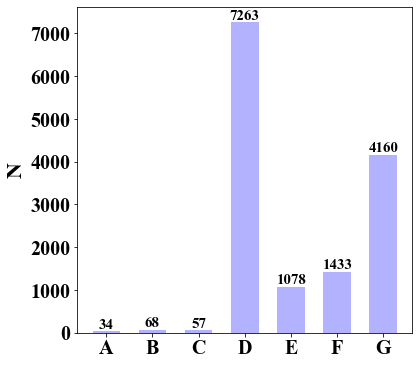

<Figure size 432x288 with 0 Axes>

In [60]:
fig= plt.figure(figsize=(6,6))          #
ax = fig.add_subplot(1,1,1) 

x=np.arange(len(num_list))
y=np.array(num_list)
plt.bar(range(len(num_list)), num_list,color='blue',width = 0.6,tick_label=name_list,alpha=0.3)
for a,b in zip(x,y):
    plt.text(a, b+0.05, '%.0f' % b, ha='center', va= 'bottom',fontsize=15)

#plt.legend(loc="best")
plt.yticks(fontproperties = 'Times New Roman')
plt.xticks(fontproperties = 'Times New Roman') 
ax.set_ylabel("N",size=22,family='Times New Roman')  
#ax.set_xlabel("",size=22,family='Times New Roman')
plt.tick_params(labelsize=20)
plt.show()
plt.savefig('500m不同区域流量分布.pdf')